# Failure Case Analysis — VoxBind Generated Samples

Identify and visualize generated ligands that exhibit **atom clashes** (inter-clash with pocket) or **very poor docking scores** (Vina dock affinity).

In [15]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np
import pandas as pd
from glob import glob
from rdkit import Chem
import nglview as nv
from IPython.display import display

## 1. Load all evaluation results into a single table

In [2]:
GEN_DIR = os.path.join(os.getcwd(), "..", "voxbind", "exps", "cbgbench", "voxbind")
PDB_DIR = os.path.join(os.getcwd(), "..", "voxbind", "dataset", "data", "crossdocked_pocket10")

pocket_dirs = sorted(glob(os.path.join(GEN_DIR, "*", "*")))
print(f"Pocket dirs: {len(pocket_dirs)}")

rows = []
for pd_path in pocket_dirs:
    # pocket family / pocket_name  →  PDB path
    rel = os.path.relpath(pd_path, GEN_DIR)  # e.g. "BSD_ASPTE_1_130_0/2z3h_A_rec_..."
    pdb_path = os.path.join(PDB_DIR, rel + ".pdb")

    geom_file = os.path.join(pd_path, "geom_eval_results.pt")
    chem_file = os.path.join(pd_path, "chem_eval_results.pt")

    # load geom results (clash info)
    geom_map = {}
    if os.path.exists(geom_file):
        for g in torch.load(geom_file, weights_only=False):
            geom_map[g["file_name"]] = g

    # load chem results (docking scores)
    if os.path.exists(chem_file):
        for c in torch.load(chem_file, weights_only=False):
            fname = os.path.basename(c["ligand_filename"])
            g = geom_map.get(fname, {})
            vina_dock = None
            try:
                vina_dock = float(c["vina"]["dock"]["affinity"])
            except Exception:
                pass
            rows.append({
                "pocket_dir": pd_path,
                "pocket_rel": rel,
                "pdb_path": pdb_path,
                "sdf_file": fname,
                "sdf_path": os.path.join(pd_path, fname),
                "smiles": c.get("smiles", ""),
                "num_atoms": c.get("num_atoms", 0),
                "vina_dock": vina_dock,
                "vina_score_only": float(c["vina"]["score_only"]["affinity"]) if c["vina"]["score_only"]["affinity"] is not None else None,
                "qed": c["chem_results"].get("qed"),
                "sa": c["chem_results"].get("sa"),
                "clash_detected": g.get("clash_detected", None),
                "inter_clash_atoms": g.get("inter_clash_atom_num", None),
                "mol_stable": g.get("mol_stable", None),
            })

df = pd.DataFrame(rows)
print(f"Total samples: {len(df)}")
print(f"\nClash detected: {df['clash_detected'].sum()} / {df['clash_detected'].notna().sum()} ({100*df['clash_detected'].mean():.1f}%)")
print(f"Vina dock scores: mean={df['vina_dock'].mean():.2f}, worst={df['vina_dock'].max():.2f}, best={df['vina_dock'].min():.2f}")
df.head()

Pocket dirs: 88
Total samples: 6553

Clash detected: 1251 / 6553 (19.1%)
Vina dock scores: mean=-7.66, worst=68.92, best=-16.72


,pocket_dir,pocket_rel,pdb_path,sdf_file,sdf_path,smiles,num_atoms,vina_dock,vina_score_only,qed,sa,clash_detected,inter_clash_atoms,mol_stable
0,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,ABL2_HUMAN_274_551_0/4xli_B_rec_4xli_1n1_lig_t...,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,samples_000.sdf,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,O=C(O)c1cccc(O)c1O,11,-5.593,-4.182,0.522491,0.91,False,0,False
1,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,ABL2_HUMAN_274_551_0/4xli_B_rec_4xli_1n1_lig_t...,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,samples_001.sdf,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,CC[C@@H]1C(=O)N(OC)C(C(=O)O)=NN1c1cccc(C)c1,21,-0.348,-6.772,0.905904,0.73,False,0,True
2,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,ABL2_HUMAN_274_551_0/4xli_B_rec_4xli_1n1_lig_t...,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,samples_002.sdf,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,CC[C@H]1CCCC[C@]1(C)C1=C(O)CC2=C(C1)OC1=C(Cc3n...,28,-11.268,-10.641,0.770230,0.58,False,0,False
3,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,ABL2_HUMAN_274_551_0/4xli_B_rec_4xli_1n1_lig_t...,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,samples_003.sdf,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,CN1C=C(C(=N)N)C=C2NN(C3=CC=CCC3)C(=O)C21,20,-7.983,-6.928,0.506534,0.60,False,0,False
4,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,ABL2_HUMAN_274_551_0/4xli_B_rec_4xli_1n1_lig_t...,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,samples_004.sdf,/home/shpark/prj-ligand/Voxbind/notebook/../vo...,CCCn1cc2c(cc1=N)N=C1c3c(N4CCCC4)cc(-c4ccccc4)n...,34,-10.038,-9.506,0.622335,0.73,True,1,False


## 2. Filter failure cases

**Atom clash**: `clash_detected == True` (inter-clash with pocket atoms)
**Poor docking**: `vina_dock > -3` (very weak or repulsive binding)

In [5]:
# ── Worst docking scores ──────────────────────────────────────────────
df_poor_dock = df[df["vina_dock"] > -3].sort_values("vina_dock", ascending=False)
print(f"Poor docking (vina_dock > -3): {len(df_poor_dock)} samples")

# ── Atom clashes with most inter-clash atoms ─────────────────────────
df_clash = df[df["clash_detected"] == True].sort_values("inter_clash_atoms", ascending=False)
print(f"Clash detected: {len(df_clash)} samples")

# ── Combined worst cases (union) ─────────────────────────────────────
df_fail = pd.concat([df_poor_dock, df_clash]).drop_duplicates(subset=["sdf_path"]).sort_values("vina_dock", ascending=False)
print(f"Union of failure cases: {len(df_fail)}")

cols = ["pocket_rel", "sdf_file", "vina_dock", "clash_detected", "inter_clash_atoms", "num_atoms", "smiles"]
df_fail[cols].head(20)

Poor docking (vina_dock > -3): 24 samples
Clash detected: 1251 samples
Union of failure cases: 1273


,pocket_rel,sdf_file,vina_dock,clash_detected,inter_clash_atoms,num_atoms,smiles
3750,NPD_THEMA_1_246_0/3pdh_A_rec_4buz_ocz_lig_tt_m...,samples_025.sdf,68.920,False,0,11,O=C(O)Nc1cccc(O)c1
3713,NOS3_HUMAN_65_480_0/4kcq_A_rec_4cwv_hw8_lig_tt...,samples_057.sdf,19.777,False,0,24,O=C1Cc2c(c(O)cc3c2-c2ccccc2[C@H](C2=NCNN2)C3)N1
5565,ROCO4_DICDI_1009_1292_0/4f1m_A_rec_4f1m_acp_li...,samples_047.sdf,17.042,True,1,27,CNC1=C(O)CC2=C3[C@H]1COCN3[C@H]1CC[C@@H](NCc3c...
3455,NOS1_HUMAN_302_723_0/3tym_A_rec_3n5v_xfh_lig_t...,samples_041.sdf,13.349,False,0,27,CC[C@@H](C)Cc1cc(C2=CC=C(S(O)(O)O)C(CCC(C)C)C2...
3449,NOS1_HUMAN_302_723_0/3tym_A_rec_3n5v_xfh_lig_t...,samples_035.sdf,12.576,False,0,22,COC(=O)N[C@@H]1C=C(C2C=CCC=C2)C=C[C@@H]1ONC(C)C
3475,NOS1_HUMAN_302_723_0/3tym_A_rec_3n5v_xfh_lig_t...,samples_061.sdf,11.914,False,0,15,CCC[C@H](C)CO[P@@](=O)(O)OP(=O)(O)O
4215,P2Y12_HUMAN_1_342_0/4pxz_A_rec_4pxz_6ad_lig_tt...,samples_008.sdf,9.100,True,3,23,CC(=O)C[C@@H]1C[C@@H](O)C(=O)[C@H]1OC1=CC2C=C(...
439,ATS5_HUMAN_262_480_0/3hy9_B_rec_3hyg_099_lig_t...,samples_030.sdf,2.990,False,0,28,C[C@H]1N(C)CCN1C(=N)C(=O)C(=O)C1=CC=C[C@@H](c2...
4929,POL_FOAMV_861_1060_0/5mma_A_rec_4ztf_x2p_lig_t...,samples_034.sdf,2.800,False,0,33,CCc1c(C)cc2c(c1O)C(=O)[C@H](O)[C@H]([C@@H](O)C...
3793,NPD_THEMA_1_246_0/3pdh_A_rec_4buz_ocz_lig_tt_m...,samples_068.sdf,1.471,False,0,20,C[C@H]1COC2=C3[C@H](C(=O)c4ccccc4N31)C(O)=CC2


## 3. Visualize failure cases

Show the pocket (cartoon + translucent surface) with the generated ligand (ball-and-stick) for the worst examples.

In [30]:
def show_pocket_ligand(pdb_path, sdf_path, title=""):
    """Render pocket + ligand with nglview."""
    view = nv.NGLWidget()

    # pocket: cartoon + translucent surface
    view.add_component(pdb_path)
    view.clear_representations(component=0)
    view.add_representation("ball+stick", selection="*", component=0, radius=0.1, aspectRatio=1.0)
    view.add_representation("surface", selection="*", surfaceType="sas", opacity=0.2, color="electrostatic", component=0)

    # ligand: ball+stick
    view.add_component(sdf_path)
    view.clear_representations(component=1)
    view.add_representation("ball+stick", selection="*", component=1)
    view.add_representation("surface", component=1, opacity=0.2, color="white", surfaceType="vws")
    
    view.center()
    view._remote_call("setSize", target="Widget", args=["500px", "500px"])

    if title:
        print(title)

    return view

### 3a. Worst docking scores

In [28]:
N_SHOW = 3
for i, (_, row) in enumerate(df_poor_dock.head(N_SHOW).iterrows()):
    label = f"#{i+1}  vina_dock={row['vina_dock']:.1f}  clash={row['clash_detected']}  atoms={row['num_atoms']}"
    print(label)
    print(f"   pocket: {row['pocket_rel']}")
    print(f"   sdf:    {row['sdf_file']}  SMILES: {row['smiles']}")
    v = show_pocket_ligand(row["pdb_path"], row["sdf_path"])
    display(v)

#1  vina_dock=68.9  clash=False  atoms=11
   pocket: NPD_THEMA_1_246_0/3pdh_A_rec_4buz_ocz_lig_tt_min_0_pocket10
   sdf:    samples_025.sdf  SMILES: O=C(O)Nc1cccc(O)c1


NGLWidget()

#2  vina_dock=19.8  clash=False  atoms=24
   pocket: NOS3_HUMAN_65_480_0/4kcq_A_rec_4cwv_hw8_lig_tt_min_0_pocket10
   sdf:    samples_057.sdf  SMILES: O=C1Cc2c(c(O)cc3c2-c2ccccc2[C@H](C2=NCNN2)C3)N1


NGLWidget()

#3  vina_dock=17.0  clash=True  atoms=27
   pocket: ROCO4_DICDI_1009_1292_0/4f1m_A_rec_4f1m_acp_lig_tt_min_0_pocket10
   sdf:    samples_047.sdf  SMILES: CNC1=C(O)CC2=C3[C@H]1COCN3[C@H]1CC[C@@H](NCc3ccccc3)[C@@H]1C2


NGLWidget()

### 3b. Worst atom clashes (most inter-clash atoms)

In [31]:
N_SHOW = 3
for i, (_, row) in enumerate(df_clash.head(N_SHOW).iterrows()):
    label = f"#{i+1}  inter_clash={row['inter_clash_atoms']}  vina_dock={row['vina_dock']:.1f}  atoms={row['num_atoms']}"
    print(label)
    print(f"   pocket: {row['pocket_rel']}")
    print(f"   sdf:    {row['sdf_file']}  SMILES: {row['smiles']}")
    v = show_pocket_ligand(row["pdb_path"], row["sdf_path"])
    display(v)

#1  inter_clash=6  vina_dock=-8.9  atoms=29
   pocket: CCPR_YEAST_69_361_0/1a2g_A_rec_4jmv_1ly_lig_tt_min_0_pocket10
   sdf:    samples_009.sdf  SMILES: O=C(O)N[C@@H]1CN(S(O)(O)O)C2=C1CCC([C@@H](c1ccccc1)N(O)[S@@](=O)O)=C2


NGLWidget()

#2  inter_clash=5  vina_dock=-8.1  atoms=26
   pocket: PPIA_HUMAN_1_165_0/2rma_A_rec_3rdd_ea4_lig_tt_docked_0_pocket10
   sdf:    samples_067.sdf  SMILES: Cc1ccc(O)c(OCCO)c1CCC=C1[C]=S(C(=N)CN([O])[O])CC1


NGLWidget()

#3  inter_clash=4  vina_dock=-7.7  atoms=23
   pocket: P2Y12_HUMAN_1_342_0/4pxz_A_rec_4pxz_6ad_lig_tt_min_0_pocket10
   sdf:    samples_012.sdf  SMILES: C[C@](S)(C[P@](=O)(O)OP(=O)(O)O)c1ccc(C(=N)CC=N)cc1


NGLWidget()

## 4. Summary statistics

Distribution of Vina dock scores and inter-clash atom counts across all generated samples, with failure thresholds highlighted.

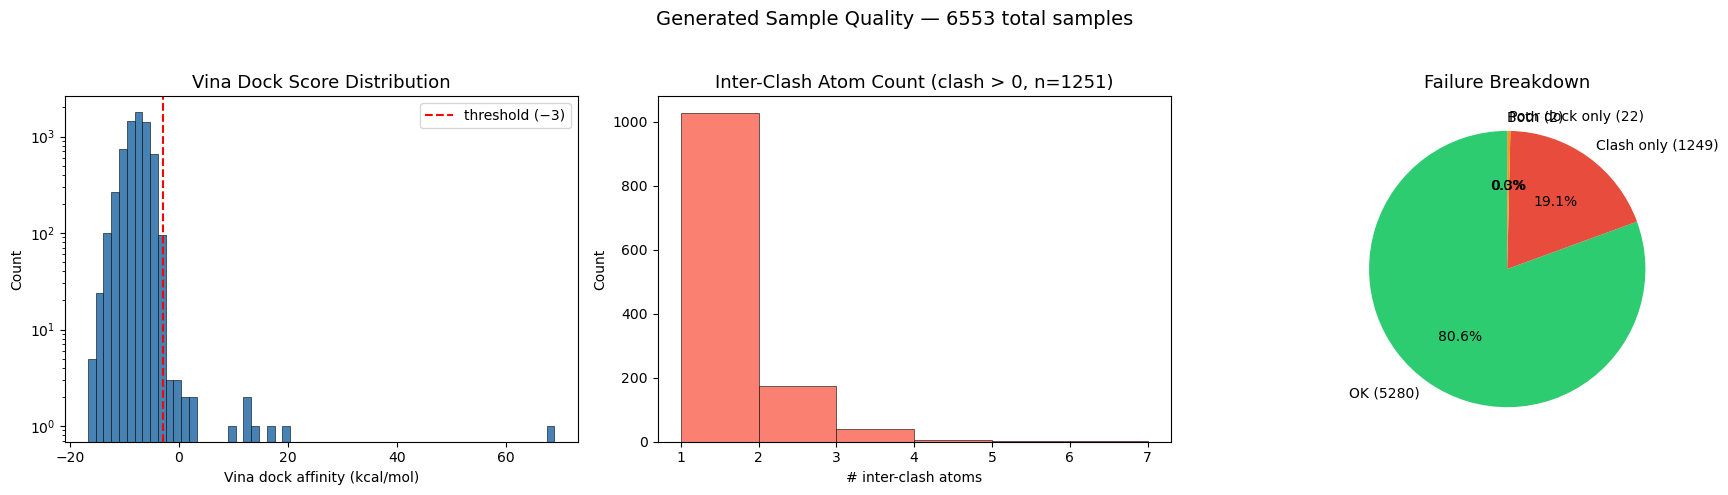


Summary:
  Total samples:     6553
  Clash only:        1249 (19.1%)
  Poor dock only:    22 (0.3%)
  Both:              2 (0.0%)
  OK:                5280 (80.6%)


In [12]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 4a. Vina dock score distribution ──────────────────────────────────
vina_vals = df["vina_dock"].dropna()
axes[0].hist(vina_vals, bins=60, color="steelblue", edgecolor="black", linewidth=0.4)
axes[0].axvline(-3, color="red", ls="--", lw=1.5, label="threshold (−3)")
axes[0].set_title("Vina Dock Score Distribution", fontsize=13)
axes[0].set_xlabel("Vina dock affinity (kcal/mol)")
axes[0].set_ylabel("Count")
axes[0].set_yscale("log")
axes[0].legend()

# ── 4b. Inter-clash atom count distribution ───────────────────────────
clash_vals = df["inter_clash_atoms"].dropna()
max_clash = int(clash_vals.max())
axes[1].hist(clash_vals[clash_vals > 0], bins=range(1, max_clash + 2), color="salmon", edgecolor="black", linewidth=0.4)
axes[1].set_title(f"Inter-Clash Atom Count (clash > 0, n={int((clash_vals > 0).sum())})", fontsize=13)
axes[1].set_xlabel("# inter-clash atoms")
axes[1].set_ylabel("Count")

# ── 4c. Failure breakdown pie chart ──────────────────────────────────
n_total = len(df)
n_clash_only = len(df_clash[~df_clash.index.isin(df_poor_dock.index)])
n_dock_only = len(df_poor_dock[~df_poor_dock.index.isin(df_clash.index)])
n_both = len(df_fail) - n_clash_only - n_dock_only
n_ok = n_total - n_clash_only - n_dock_only - n_both

labels = [f"OK ({n_ok})", f"Clash only ({n_clash_only})", f"Poor dock only ({n_dock_only})", f"Both ({n_both})"]
sizes = [n_ok, n_clash_only, n_dock_only, n_both]
colors = ["#2ecc71", "#e74c3c", "#f39c12", "#8e44ad"]
axes[2].pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
axes[2].set_title("Failure Breakdown", fontsize=13)

fig.suptitle(f"Generated Sample Quality — {n_total} total samples", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print(f"\nSummary:")
print(f"  Total samples:     {n_total}")
print(f"  Clash only:        {n_clash_only} ({100*n_clash_only/n_total:.1f}%)")
print(f"  Poor dock only:    {n_dock_only} ({100*n_dock_only/n_total:.1f}%)")
print(f"  Both:              {n_both} ({100*n_both/n_total:.1f}%)")
print(f"  OK:                {n_ok} ({100*n_ok/n_total:.1f}%)")

## 5. Failure cases by pocket

Which pockets have the highest failure rates?

In [10]:
# ── Per-pocket failure stats ──────────────────────────────────────────
pocket_stats = df.groupby("pocket_rel").agg(
    n_samples=("sdf_file", "count"),
    n_clash=("clash_detected", "sum"),
    mean_vina=("vina_dock", "mean"),
    worst_vina=("vina_dock", "max"),
    mean_inter_clash=("inter_clash_atoms", "mean"),
).reset_index()
pocket_stats["clash_rate"] = pocket_stats["n_clash"] / pocket_stats["n_samples"] * 100
pocket_stats = pocket_stats.sort_values("clash_rate", ascending=False)

print("Top 15 pockets by clash rate:")
pocket_stats.head(15)

Top 15 pockets by clash rate:


,pocket_rel,n_samples,n_clash,mean_vina,worst_vina,mean_inter_clash,clash_rate
66,PPIA_HUMAN_1_165_0/2rma_A_rec_3rdd_ea4_lig_tt_...,71,64,-8.763141,-6.789,1.887324,90.140845
32,IDHP_HUMAN_40_452_0/4ja8_B_rec_4ja8_1k9_lig_tt...,75,50,-10.079427,-7.358,0.986667,66.666667
53,NR1H4_HUMAN_258_486_0/5q0k_A_rec_5q0q_9ld_lig_...,86,42,-8.906209,-5.229,0.674419,48.837209
56,P2Y12_HUMAN_1_342_0/4pxz_A_rec_4pxz_6ad_lig_tt...,80,39,-7.844350,9.100,0.662500,48.750000
44,NEP_HUMAN_54_750_0/1r1h_A_rec_1r1h_bir_lig_tt_...,66,32,-8.038864,-5.090,0.666667,48.484848
39,M3K14_HUMAN_321_678_0/4g3d_B_rec_4idv_13v_lig_...,74,32,-7.299203,-4.668,0.594595,43.243243
14,CCPR_YEAST_69_361_0/1a2g_A_rec_4jmv_1ly_lig_tt...,87,36,-7.433897,-3.290,0.689655,41.379310
21,DPP2_HUMAN_27_492_0/3jyh_A_rec_3n0t_opy_lig_tt...,93,34,-6.239161,-4.170,0.494624,36.559140
54,ODBB_THET8_1_324_0/1umd_B_rec_1umb_tdp_lig_tt_...,76,26,-7.479171,-5.240,0.394737,34.210526
59,PAC_ECOLX_27_846_0/1ai4_A_rec_1ai5_mnp_lig_tt_...,92,31,-6.742957,-4.975,0.347826,33.695652


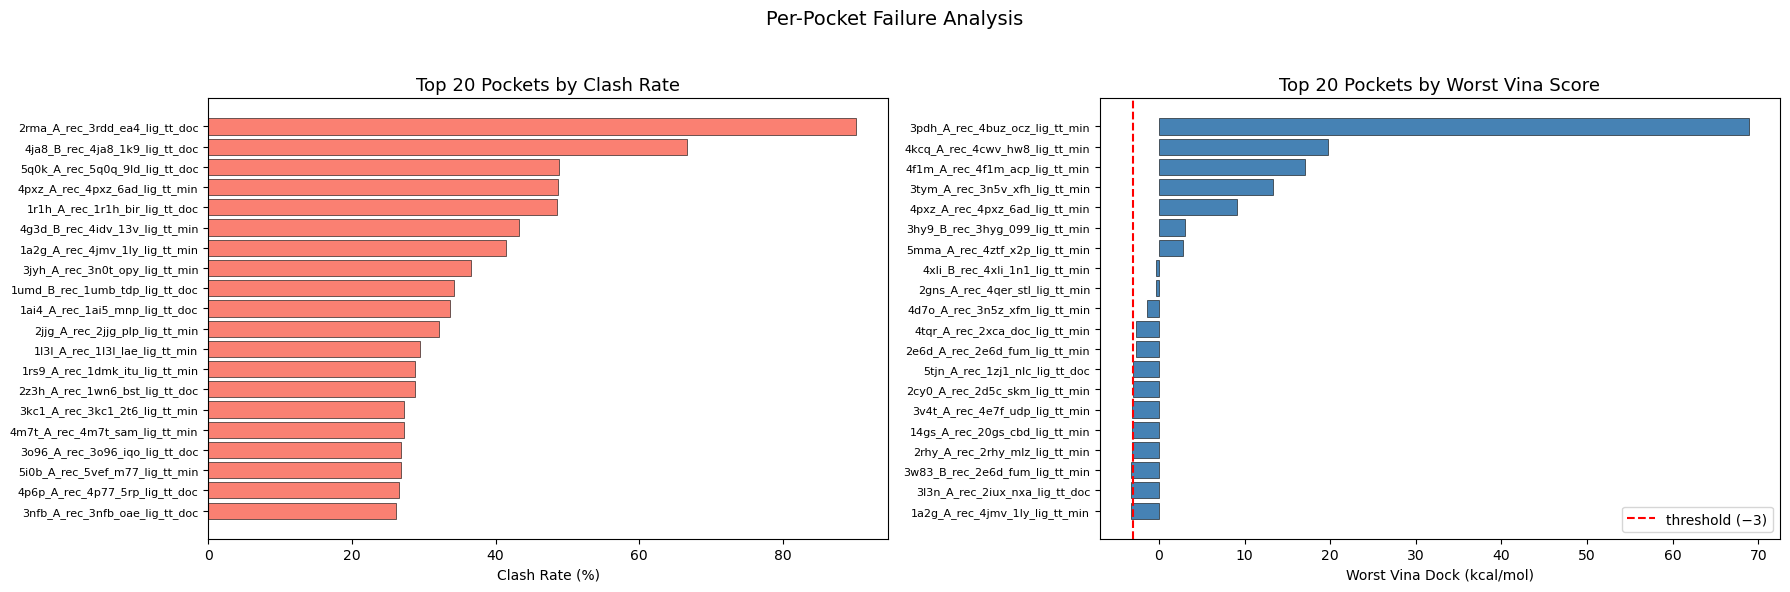

In [11]:
# ── Bar plot: clash rate by pocket ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top = pocket_stats.head(20)
short_names = [r.split("/")[-1][:30] for r in top["pocket_rel"]]
axes[0].barh(short_names[::-1], top["clash_rate"].values[::-1], color="salmon", edgecolor="black", linewidth=0.4)
axes[0].set_xlabel("Clash Rate (%)")
axes[0].set_title("Top 20 Pockets by Clash Rate", fontsize=13)
axes[0].tick_params(axis="y", labelsize=8)

# ── Bar plot: worst vina by pocket ────────────────────────────────────
top_vina = pocket_stats.sort_values("worst_vina", ascending=False).head(20)
short_names_v = [r.split("/")[-1][:30] for r in top_vina["pocket_rel"]]
axes[1].barh(short_names_v[::-1], top_vina["worst_vina"].values[::-1], color="steelblue", edgecolor="black", linewidth=0.4)
axes[1].axvline(-3, color="red", ls="--", lw=1.5, label="threshold (−3)")
axes[1].set_xlabel("Worst Vina Dock (kcal/mol)")
axes[1].set_title("Top 20 Pockets by Worst Vina Score", fontsize=13)
axes[1].tick_params(axis="y", labelsize=8)
axes[1].legend()

fig.suptitle("Per-Pocket Failure Analysis", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()